In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import CoolTrack modules
from cooltrack.constants import INDEPENDENT_DIMS
from cooltrack.data_loader import load_and_clean_grid_pandas
from cooltrack.models import ThermalEvolutionModels

# Plotting style
sns.set_theme(style="whitegrid", context="talk")

# Data Path
GRID_FILE_PATH = "../data/HADES_grid/hades_processed_grid.parquet"

In [4]:
print("Loading data...")
# Load the data using our optimized PyArrow loader
df = load_and_clean_grid_pandas(GRID_FILE_PATH)

# For rapid evaluation testing, we can use a slice or the full dataset.
# Let's use the full loaded dataset here.
print(f"Data loaded successfully! Shape: {df.shape}")

2026-02-23 01:00:58,630 - INFO - Loading filtered parquet file: ../data/HADES_grid/hades_processed_grid.parquet...


Loading data...


2026-02-23 01:00:58,884 - INFO - Grid loaded successfully. Final shape: (91613, 13)


Data loaded successfully! Shape: (91613, 13)


In [5]:
print("Training models...")
ml_engine = ThermalEvolutionModels()
ml_engine.train_models(df, tune_hyperparameters=False)

# Prepare the exact same test sets for evaluation
X_tint = df[INDEPENDENT_DIMS + ['S_physical']]
y_tint = df['T_int']
_, X_tint_test, _, y_tint_test = train_test_split(X_tint, y_tint, test_size=0.2, random_state=42)

X_dsdt = df[INDEPENDENT_DIMS + ['S_physical', 'T_int']]
y_dsdt = df['abs_log_dsdt']
_, X_dsdt_test, _, y_dsdt_test = train_test_split(X_dsdt, y_dsdt, test_size=0.2, random_state=42)

# Generate predictions on the unseen test data
tint_preds = ml_engine.tint_model.predict(X_tint_test)
dsdt_preds = ml_engine.dsdt_model.predict(X_dsdt_test)
print("Predictions generated!")

2026-02-23 01:01:01,458 - INFO - Training T_int state model...


Training models...


2026-02-23 01:01:03,770 - INFO - T_int model R^2: 0.9643
2026-02-23 01:01:03,786 - INFO - Training baseline dS/dt model...
2026-02-23 01:01:06,558 - INFO - dS/dt model test R^2: 0.8424


Predictions generated!


In [6]:
print("=== T_int Model Evaluation ===")
print(f"R^2 Score: {r2_score(y_tint_test, tint_preds):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_tint_test, tint_preds):.2f} K")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_tint_test, tint_preds)):.2f} K")

print("\n=== dS/dt Model Evaluation (Log10 scale) ===")
print(f"R^2 Score: {r2_score(y_dsdt_test, dsdt_preds):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_dsdt_test, dsdt_preds):.4f} dex")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_dsdt_test, dsdt_preds)):.4f} dex")

=== T_int Model Evaluation ===
R^2 Score: 0.9657
Mean Absolute Error (MAE): 31.35 K
Root Mean Squared Error (RMSE): 58.55 K

=== dS/dt Model Evaluation (Log10 scale) ===
R^2 Score: 0.8424
Mean Absolute Error (MAE): 0.1452 dex
Root Mean Squared Error (RMSE): 0.5132 dex


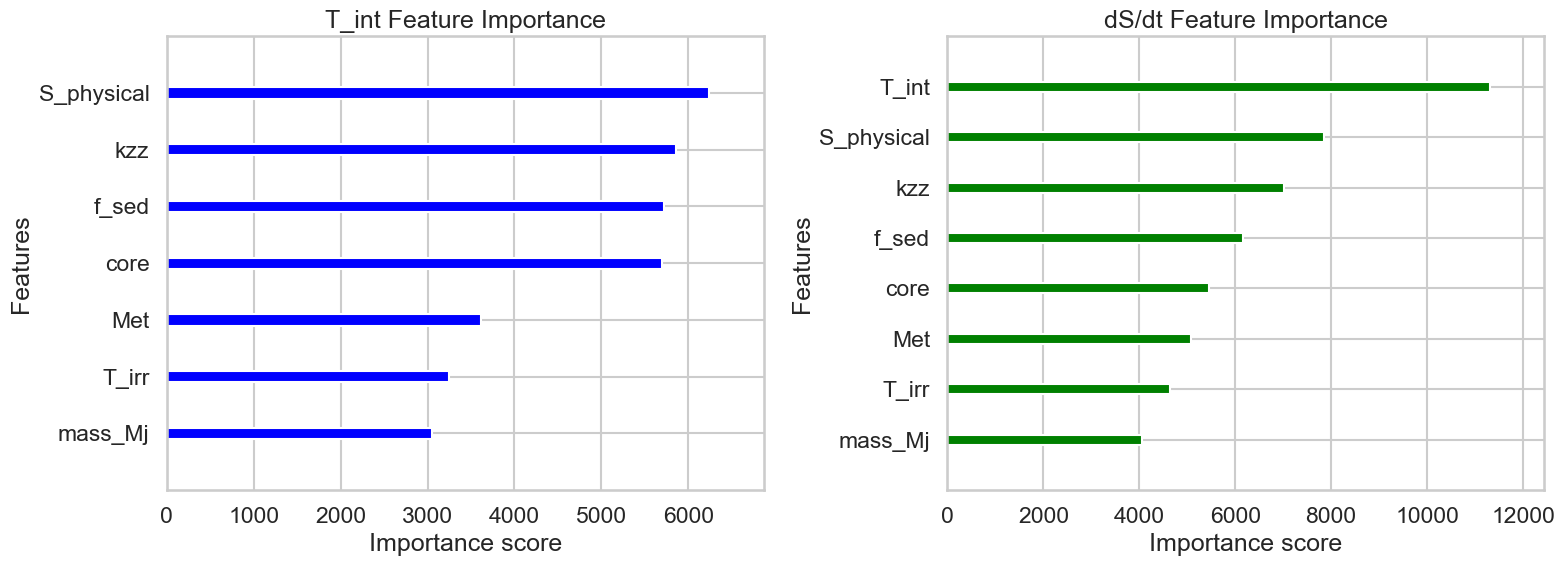

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# T_int Feature Importances
xgb.plot_importance(ml_engine.tint_model, ax=axes[0], importance_type='weight', 
                    title='T_int Feature Importance', color='blue', show_values=False)
axes[0].set_yticklabels(X_tint_test.columns)

# dS/dt Feature Importances
xgb.plot_importance(ml_engine.dsdt_model, ax=axes[1], importance_type='weight', 
                    title='dS/dt Feature Importance', color='green', show_values=False)
axes[1].set_yticklabels(X_dsdt_test.columns)

plt.tight_layout()
plt.show()